# Lecture 13 (B11): Continuous-time heterogeneous agents, numerics

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §8.7 (Numerical methods for CT-HA)  
**Notebook role:** exercise  
**Original live-course source:** `lectures/day6/code/09_PINN_Exercise.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Exercise: Solving a Simple ODE with PINNs

*Companion notebook to **Day 6 — PINNs and Continuous-Time Heterogeneous Agents** (Chapters 7–8 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

In this exercise you will implement a **Physics-Informed Neural Network (PINN)** from scratch
to solve a simple ordinary differential equation.  The goal is to solidify your understanding
of the core PINN ingredients — network architecture, automatic differentiation for computing
derivatives, residual-based loss functions, and boundary-condition enforcement — before
tackling the more involved HJB equations we saw in the lecture.

You will solve the second-order ODE $u''(x) + u(x) = 0$ on the interval $[0,\pi]$ with
Dirichlet boundary conditions $u(0)=0$ and $u(\pi)=0$.  The analytical solution is
$u(x) = \sin(x)$, so you can check your results exactly.

**Time budget:** ~30 minutes (Tasks 1–4).  A bonus task on hard boundary conditions is
provided for students who finish early.

> **In-class exercise** (Day 6, Block 1 — PINNs Foundations & Economic Applications)

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 13

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# torch.compile is wrapped on per-batch steps below for JIT speedups.
# PINN-style losses use torch.autograd.grad with create_graph=True (double
# backward), which the default aot_autograd backend in PyTorch 2.x does not
# yet support. We use backend='eager' and allow dynamo to fall back to eager
# Python whenever it cannot trace a sub-call (e.g. clip_grad_norm_).
import torch._dynamo
torch._dynamo.config.suppress_errors = True


Device: cpu


## The Problem

We seek a function $u(x)$ satisfying the **second-order linear ODE**

$$u''(x) + u(x) = 0, \qquad x \in [0, \pi],$$

with **Dirichlet boundary conditions**

$$u(0) = 0, \qquad u(\pi) = 0.$$

**Analytical solution.** One can verify by direct substitution that $u(x) = \sin(x)$
satisfies both the ODE and the boundary conditions:
- $u''(x) = -\sin(x)$, so $u''(x) + u(x) = -\sin(x) + \sin(x) = 0$. [OK]
- $u(0) = \sin(0) = 0$, $u(\pi) = \sin(\pi) = 0$. [OK]

Our goal is to approximate this solution using a neural network trained with a
**physics-informed loss** — i.e., we penalise the ODE residual $R(x) = u''(x) + u(x)$
at randomly sampled collocation points, plus a boundary penalty.

## Task 1: Implement the PINN Network (5 min)

Build a simple **multi-layer perceptron (MLP)** with:
- **Input:** 1 neuron (the coordinate $x$)
- **Hidden layers:** 2 layers of 32 neurons each, with `tanh` activation
- **Output:** 1 neuron (the predicted $u(x)$)

Fill in the blanks in the class below.

In [2]:
class PINN(nn.Module):
    def __init__(self, n_hidden=32):
        super().__init__()
        # TODO: Define 3 linear layers:
        # self.fc1 = nn.Linear(1, n_hidden)
        # self.fc2 = nn.Linear(n_hidden, n_hidden)
        # self.fc3 = nn.Linear(n_hidden, 1)
        pass

    def forward(self, x):
        # TODO: Implement forward pass with tanh activations
        # h = torch.tanh(self.fc1(x))
        # h = torch.tanh(self.fc2(h))
        # return self.fc3(h)
        pass

### Solution

In [3]:
class PINN(nn.Module):
    def __init__(self, n_hidden=32):
        super().__init__()
        self.fc1 = nn.Linear(1, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_hidden)
        self.fc3 = nn.Linear(n_hidden, 1)

    def forward(self, x):
        h = torch.tanh(self.fc1(x))
        h = torch.tanh(self.fc2(h))
        return self.fc3(h)

## Task 2: Implement the PDE Residual (10 min)

The PINN loss requires evaluating the **ODE residual** $R(x) = u''(x) + u(x)$ at every
collocation point.  Since the network $u_\theta(x)$ is a composition of differentiable
operations, we can compute its derivatives **exactly** using PyTorch's automatic
differentiation engine `torch.autograd.grad`.

**Steps:**
1. Evaluate $u = \text{model}(x)$.
2. Compute the first derivative $u_x = \partial u / \partial x$ using `torch.autograd.grad`.
   Pass `create_graph=True` so that the computational graph is retained for the next step.
3. Compute the second derivative $u_{xx} = \partial u_x / \partial x$ using `torch.autograd.grad`
   again (with `create_graph=True` so we can back-propagate through the whole expression).
4. Return $R(x) = u_{xx} + u$.

In [4]:
def pde_residual(model, x):
    """Compute the ODE residual R(x) = u''(x) + u(x)."""
    x.requires_grad_(True)
    u = model(x)

    # TODO: Compute first derivative u_x using torch.autograd.grad
    # u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
    #                           create_graph=True)[0]

    # TODO: Compute second derivative u_xx
    # u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
    #                            create_graph=True)[0]

    # TODO: Return the residual u_xx + u
    # return u_xx + u
    pass

### Solution

In [5]:
def pde_residual(model, x):
    """Compute the ODE residual R(x) = u''(x) + u(x)."""
    x.requires_grad_(True)
    u = model(x)

    # First derivative
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                              create_graph=True)[0]

    # Second derivative
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                               create_graph=True)[0]

    # ODE residual
    return u_xx + u

## Task 3: Implement the Training Loop (10 min)

We train the PINN by minimising a composite loss:

$$\mathcal{L} = \underbrace{\frac{1}{N}\sum_{i=1}^{N} R(x_i)^2}_{\text{PDE residual loss}}
             + \lambda \underbrace{\bigl[u_\theta(0)^2 + u_\theta(\pi)^2\bigr]}_{\text{boundary loss}},$$

where the collocation points $\{x_i\}$ are sampled uniformly from $(0,\pi)$ and $\lambda=10$
is a penalty weight for the boundary conditions.

**Instructions:**
1. Sample 256 collocation points uniformly in $[0,\pi]$.
2. Compute the mean-squared PDE residual.
3. Evaluate the model at $x=0$ and $x=\pi$ and penalise deviations from zero.
4. Combine into a total loss and call `.backward()` / `optimizer.step()`.
5. Train for 3000 iterations (classroom setting; production: 10000).

In [6]:
model = PINN(n_hidden=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_iters = 3000   # Classroom: 3000; Production: 10000
loss_history = []

for it in range(1, n_iters + 1):
    optimizer.zero_grad()

    # Sample collocation points in [0, pi]
    x_int = (torch.rand(256, 1, device=device) * torch.pi).requires_grad_(True)

    # TODO: Compute PDE residual loss (mean squared residual)
    # R = pde_residual(model, x_int)
    # loss_pde = torch.mean(R ** 2)

    # TODO: Compute boundary loss at x=0 and x=pi
    # u_0  = model(torch.zeros(1, 1, device=device))
    # u_pi = model(torch.full((1, 1), torch.pi, device=device))
    # loss_bc = u_0 ** 2 + u_pi ** 2

    # TODO: Total loss = PDE + penalty * BC
    # loss = loss_pde + 10.0 * loss_bc

    # loss.backward()
    # optimizer.step()
    # loss_history.append(loss.item())
    pass

# print(f"Final loss: {loss_history[-1]:.3e}")

### Solution

In [7]:
torch.manual_seed(42)

model = PINN(n_hidden=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_iters = 3000   # Classroom: 3000; Production: 10000
loss_history = []


def train_step(x_int):
    optimizer.zero_grad()
    R = pde_residual(model, x_int)
    loss_pde = torch.mean(R ** 2)
    u_0  = model(torch.zeros(1, 1, device=device))
    u_pi = model(torch.full((1, 1), torch.pi, device=device))
    loss_bc = u_0 ** 2 + u_pi ** 2
    loss = loss_pde + 10.0 * loss_bc
    loss.backward()
    optimizer.step()
    return loss, loss_pde, loss_bc


# torch.compile per-batch step (backend="eager", fullgraph=False:
# residual uses torch.autograd.grad with create_graph=True for second derivatives,
# which the default aot_autograd backend in PyTorch 2.x does not yet support.)
train_step = torch.compile(train_step, fullgraph=False, backend="eager")

for it in range(1, n_iters + 1):
    x_int = (torch.rand(256, 1, device=device) * torch.pi).requires_grad_(True)
    loss, loss_pde, loss_bc = train_step(x_int)
    loss_history.append(loss.item())

    if it % 500 == 0 or it == 1:
        print(f"Iter {it:>5d}/{n_iters}  |  loss = {loss.item():.3e}  "
              f"(PDE = {loss_pde.item():.3e}, BC = {loss_bc.item():.3e})")

print(f"\nTraining complete.  Final loss: {loss_history[-1]:.3e}")


Iter     1/3000  |  loss = 7.646e-01  (PDE = 4.876e-02, BC = 7.158e-02)


Iter   500/3000  |  loss = 2.907e-06  (PDE = 2.902e-06, BC = 4.961e-10)


Iter  1000/3000  |  loss = 3.764e-06  (PDE = 3.761e-06, BC = 3.099e-10)


Iter  1500/3000  |  loss = 2.381e-06  (PDE = 2.373e-06, BC = 8.041e-10)


Iter  2000/3000  |  loss = 3.072e-06  (PDE = 3.062e-06, BC = 1.012e-09)


Iter  2500/3000  |  loss = 2.179e-06  (PDE = 2.178e-06, BC = 1.908e-10)


Iter  3000/3000  |  loss = 1.736e-06  (PDE = 1.726e-06, BC = 9.537e-10)

Training complete.  Final loss: 1.736e-06


## Task 4: Evaluate and Plot (5 min)

Compare the trained PINN solution $u_\theta(x)$ against the analytical solution $\sin(x)$.
The code below is provided for you — just run the cell.

Max absolute error: 1.008e+00


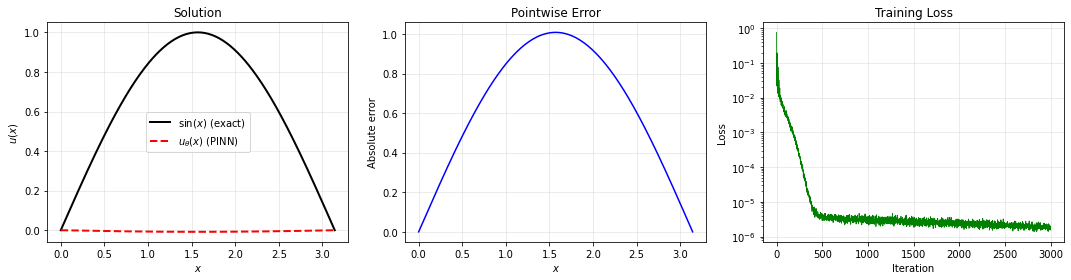

In [8]:
# ---------- evaluate on a fine grid ----------
x_eval = torch.linspace(0, torch.pi, 300, device=device).unsqueeze(1)

with torch.no_grad():
    u_pred = model(x_eval).cpu().numpy().flatten()

x_np = x_eval.cpu().numpy().flatten()
u_exact = np.sin(x_np)

max_err = np.max(np.abs(u_pred - u_exact))
print(f"Max absolute error: {max_err:.3e}")

# ---------- three-panel plot ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) PINN vs analytical
axes[0].plot(x_np, u_exact, "k-", lw=2, label=r"$\sin(x)$ (exact)")
axes[0].plot(x_np, u_pred, "r--", lw=2, label=r"$u_\theta(x)$ (PINN)")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$u(x)$")
axes[0].set_title("Solution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) absolute error
axes[1].plot(x_np, np.abs(u_pred - u_exact), "b-", lw=1.5)
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel("Absolute error")
axes[1].set_title("Pointwise Error")
axes[1].grid(True, alpha=0.3)

# (c) training loss
axes[2].semilogy(loss_history, "g-", lw=0.8)
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Loss")
axes[2].set_title("Training Loss")
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Bonus: Hard Boundary Conditions

In the approach above we enforced the boundary conditions $u(0)=0$ and $u(\pi)=0$ via
a **soft penalty** in the loss function.  An alternative is to **build the boundary
conditions directly into the network ansatz** so that they are satisfied exactly,
regardless of the network weights.

**Idea:** Define the PINN output as

$$\tilde{u}(x) = x\,(\pi - x)\,N(x;\theta),$$

where $N(x;\theta)$ is the raw network output.  Then:
- $\tilde{u}(0) = 0 \cdot (\pi - 0) \cdot N(0;\theta) = 0$ exactly.
- $\tilde{u}(\pi) = \pi \cdot 0 \cdot N(\pi;\theta) = 0$ exactly.

With hard BCs the boundary loss term is no longer needed — you only minimise the PDE
residual.  Try implementing this as a stretch goal.

In [9]:
# Bonus: Implement hard boundary conditions
# ==========================================
# Step 1: Define a wrapper that enforces BCs exactly
#
# def hard_bc_output(model, x):
#     """Return x * (pi - x) * model(x), which is zero at x=0 and x=pi."""
#     return x * (torch.pi - x) * model(x)
#
# Step 2: Modify pde_residual to use hard_bc_output instead of model(x) directly
#
# def pde_residual_hard(model, x):
#     x.requires_grad_(True)
#     u = hard_bc_output(model, x)
#     u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
#                               create_graph=True)[0]
#     u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
#                                create_graph=True)[0]
#     return u_xx + u
#
# Step 3: Retrain with only PDE loss (no boundary term needed!)
# model_hard = PINN(n_hidden=32).to(device)
# optimizer_hard = torch.optim.Adam(model_hard.parameters(), lr=1e-3)
# ...
# loss = torch.mean(R ** 2)   # no loss_bc term

## Summary

1. **PINNs solve differential equations by minimising residuals.** Instead of discretising
   the domain onto a grid, we parameterise the solution with a neural network and penalise
   the ODE/PDE residual at randomly sampled collocation points.

2. **Automatic differentiation computes derivatives exactly.** PyTorch's `torch.autograd.grad`
   gives us $u'(x)$, $u''(x)$, etc. without finite differences — this is both more accurate
   and trivially extends to higher dimensions.

3. **Boundary conditions can be soft (penalty) or hard (built into the ansatz).**
   Soft BCs add a penalty term to the loss; hard BCs multiply the network output by a
   function that vanishes at the boundaries, eliminating the need for a penalty altogether.

4. **This 1D example extends directly to HJB equations in economics.** The cake-eating
   HJB notebook (04) uses the same ingredients — a network, autograd derivatives, and
   a residual loss — but with a nonlinear ODE arising from dynamic optimisation.
   The jump from $u'' + u = 0$ to the HJB is conceptual (economic structure), not
   methodological (the PINN machinery is identical).